# OIBSIP Task 4 – Sentiment Analysis
**Author:** Abhishek Italiya  
**Domain:** Data Analytics Internship (Oasis Infobyte)  
**Project:** Task 4 – Sentiment Analysis on Public Twitter Dataset  

---

## 1. Project Introduction

### What is Sentiment Analysis?
**Sentiment Analysis** (also known as opinion mining) is a Natural Language Processing (NLP) technique used to determine the emotional tone behind a body of text. It classifies digital text into categories such as **Positive**, **Negative**, or **Neutral** by analyzing the words, context, and semantic structures present in the text.

### Why is Sentiment Analysis Useful?
In today's digital era, millions of tweets, product reviews, feedback forms, and customer support tickets are generated daily. Processing this vast volume of unstructured textual data manually is impossible. Automated sentiment analysis allows organizations to instantly quantify public sentiment, extract actionable insights, and make data-driven decisions at scale.

### How Businesses Use Sentiment Analysis
1. **Brand Reputation Management:** Monitoring social media mentions (e.g., Twitter/X) in real-time to catch emerging public relations crises or gauge brand perception.
2. **Product Review Analysis:** Aggregating customer feedback to identify praised features or flag recurring product defects.
3. **Customer Support Prioritization:** Automatically routing frustrated or negative tweets to high-priority escalation queues.
4. **Market Research & Competitive Intelligence:** Comparing public sentiment towards a brand vs. key competitors during marketing campaigns or product launches.

### Objective of This Project
The goal of this project is to build an end-to-end Machine Learning NLP pipeline that accurately classifies social media text into **3 sentiment classes** (**Positive**, **Negative**, **Neutral**).

### Machine Learning & NLP Techniques Used
* **Data Cleaning & Text Preprocessing:** Lowercasing, noise/regex filtering (@mentions, URLs, special characters), stopword filtering (preserving key negations), and Lemmatization with NLTK `WordNetLemmatizer`.
* **Feature Extraction:** `TfidfVectorizer` (Term Frequency-Inverse Document Frequency) using unigrams and bigrams.
* **Classifiers:** 
  1. **Multinomial Naive Bayes (`MultinomialNB`)** - A probabilistic text classifier based on Bayes' theorem.
  2. **Logistic Regression (`LogisticRegression`)** - A linear classification model well-suited for high-dimensional TF-IDF sparse matrices.
* **Evaluation Metrics:** Accuracy, Precision, Recall, Weighted & Macro F1-scores, Confusion Matrices, WordClouds, and Error Analysis.


In [1]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support

# Download required NLTK data modules cleanly
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# Ensure output directories exist
os.makedirs("../data/raw", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../outputs/charts", exist_ok=True)
os.makedirs("../outputs/models", exist_ok=True)
os.makedirs("../outputs/reports", exist_ok=True)

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"


---
## 2. Load Dataset

We utilize the **Cardiff NLP TweetEval** standard Twitter Sentiment Analysis dataset (benchmark for Twitter NLP research published at SemEval / EMNLP). The dataset contains 45,615 tweets annotated into 3 sentiment classes: **Positive**, **Negative**, and **Neutral**.

Dataset path: `data/raw/sentiment_dataset.csv`


In [2]:
# Load the dataset
data_path = "../data/raw/sentiment_dataset.csv"
df_raw = pd.read_csv(data_path)

print("=== FIRST 5 ROWS ===")
display(df_raw.head())

print("=== LAST 5 ROWS ===")
display(df_raw.tail())

print(f"Dataset Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
print("\n=== DATA TYPES & INFO ===")
df_raw.info()

print("\n=== MISSING VALUES ===")
print(df_raw.isnull().sum())

print(f"\nDuplicate Rows Count: {df_raw.duplicated().sum()}")


=== FIRST 5 ROWS ===


,clean_text,category
0,"""QT @user In the original draft of the 7th boo...",Positive
1,"""Ben Smith / Smith (concussion) remains out of...",Neutral
2,Sorry bout the stream last night I crashed out...,Neutral
3,Chase Headley's RBI double in the 8th inning o...,Neutral
4,@user Alciato: Bee will invest 150 million in ...,Positive


=== LAST 5 ROWS ===


,clean_text,category
45610,"@user \""""So amazing to have the beautiful Lady...",Positive
45611,"9 September has arrived, which means Apple's n...",Positive
45612,Leeds 1-1 Sheff Wed. Giuseppe Bellusci securin...,Positive
45613,@user no I'm in hilton head till the 8th lol g...,Neutral
45614,WASHINGTON (Reuters) - U.S. Vice President Joe...,Neutral


Dataset Shape: 45,615 rows x 2 columns

=== DATA TYPES & INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 45615 entries, 0 to 45614
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   clean_text  45615 non-null  str  
 1   category    45615 non-null  str  
dtypes: str(2)
memory usage: 712.9 KB

=== MISSING VALUES ===
clean_text    0
category      0
dtype: int64

Duplicate Rows Count: 25


---
## 3. Data Cleaning

Data cleaning is essential to remove noise and ensure dataset integrity before preprocessing.

### Cleaning Strategy:
1. **Missing Data Handling:** Check for null values in text (`clean_text`) or label (`category`) columns and remove them.
2. **Duplicate Inspection:** Inspect duplicate tweet texts. If duplicate texts have conflicting sentiment labels, remove them to prevent model confusion during training. If duplicate texts have identical labels, keep the first occurrence.
3. **Empty Text Handling:** Remove entries that consist solely of whitespace.


In [3]:
# 1. Drop missing rows if any
df_clean = df_raw.dropna(subset=['clean_text', 'category']).copy()
df_clean['clean_text'] = df_clean['clean_text'].astype(str)

# 2. Inspect duplicate tweets with conflicting labels
dup_text = df_clean[df_clean.duplicated(subset=['clean_text'], keep=False)]
print(f"Total rows with duplicate text: {len(dup_text)}")

if len(dup_text) > 0:
    conflicting = dup_text.groupby('clean_text')['category'].nunique()
    conflicting_texts = conflicting[conflicting > 1].index
    print(f"Duplicate texts with conflicting sentiment labels: {len(conflicting_texts)}")
    
    # Remove rows with conflicting labels
    df_clean = df_clean[~df_clean['clean_text'].isin(conflicting_texts)]
    # Drop remaining exact duplicate text records
    df_clean = df_clean.drop_duplicates(subset=['clean_text'], keep='first')

# 3. Strip whitespace & remove empty strings
df_clean = df_clean[df_clean['clean_text'].str.strip() != ''].copy()

print(f"Cleaned Dataset Shape: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns")


Total rows with duplicate text: 53
Duplicate texts with conflicting sentiment labels: 3
Cleaned Dataset Shape: 45,584 rows x 2 columns


---
## 4. Sentiment Class Distribution

Let's examine the distribution of the 3 sentiment classes (**Neutral**, **Positive**, **Negative**).


,Sentiment Class,Count,Percentage (%)
0,Neutral,20654,45.31
1,Positive,17839,39.13
2,Negative,7091,15.56


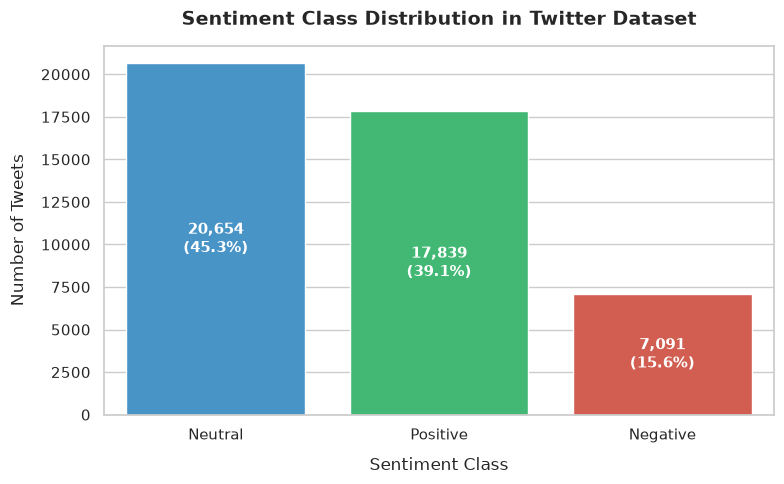

Chart saved to ../outputs/charts/sentiment_distribution.png


In [4]:
# Class distribution
dist_counts = df_clean['category'].value_counts()
dist_pct = (df_clean['category'].value_counts(normalize=True) * 100).round(2)

dist_summary = pd.DataFrame({
    'Sentiment Class': dist_counts.index,
    'Count': dist_counts.values,
    'Percentage (%)': dist_pct.values
})
display(dist_summary)

# Plot Class Distribution
plt.figure(figsize=(8, 5))
palette = {'Neutral': '#3498db', 'Positive': '#2ecc71', 'Negative': '#e74c3c'}
ax = sns.barplot(data=dist_summary, x='Sentiment Class', y='Count', hue='Sentiment Class', palette=palette, legend=False)

plt.title("Sentiment Class Distribution in Twitter Dataset", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Sentiment Class", fontsize=12, labelpad=10)
plt.ylabel("Number of Tweets", fontsize=12, labelpad=10)

for p in ax.patches:
    height = p.get_height()
    pct = (height / len(df_clean)) * 100
    ax.annotate(f"{int(height):,}\n({pct:.1f}%)",
                (p.get_x() + p.get_width() / 2., height / 2),
                ha='center', va='center', fontsize=11, color='white', fontweight='bold')

plt.tight_layout()
chart_path = "../outputs/charts/sentiment_distribution.png"
plt.savefig(chart_path, dpi=300)
plt.show()
print(f"Chart saved to {chart_path}")


### Observations on Class Distribution:
* **Neutral** is the most common sentiment class with **20,654 tweets (45.31%)**.
* **Positive** is the second largest class with **17,839 tweets (39.13%)**.
* **Negative** constitutes **7,091 tweets (15.56%)**.
* **Imbalance Assessment:** The dataset displays moderate class imbalance, with Negative tweets representing ~15.56% of total data. This imbalance can affect model recall on the minority Negative class. Thus, stratified sampling during train/test split and evaluating **Macro/Weighted F1-scores** is critical.


---
## 5. Text Preprocessing

Raw tweet text contains noisy features such as `@user` mentions, URLs, hashtags, punctuation, special characters, and non-informative stop words.

### Preprocessing Pipeline Steps:
1. **Lowercasing:** Convert all characters to lowercase for consistency.
2. **Regex Cleansing:** Remove URLs (`http...`), user handles (`@user`), and non-alphabetic special characters.
3. **Smart Stopword Removal:** Remove standard English stopwords using NLTK, but **preserve negation words** (e.g., `not`, `no`, `nor`, `never`, `cannot`) as they drastically shift sentence sentiment.
4. **Lemmatization:** Reduce words to their root base form (lemma) using NLTK `WordNetLemmatizer` (e.g., *running* -> *run*, *better* -> *good*), which retains natural language readability better than stemming.


In [5]:
# Define stop words while retaining negations
stop_words = set(stopwords.words('english'))
negation_words = {'no', 'not', 'nor', 'neither', 'never', 'none', 'cannot', 'cant', 
                  'couldnt', 'didnt', 'doesnt', 'dont', 'hadnt', 'hasnt', 'havent', 
                  'isnt', 'mightnt', 'mustnt', 'neednt', 'shouldnt', 'wasnt', 'werent', 'wont', 'wouldnt'}
custom_stopwords = stop_words - negation_words
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text).lower()
    # Remove URLs and user mentions (@user)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+', '', text)
    # Remove numbers & special characters
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize
    tokens = text.split()
    # Remove stopwords and lemmatize
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in custom_stopwords and len(word) > 1]
    return " ".join(cleaned_tokens)

# Apply preprocessing
df_clean['processed_text'] = df_clean['clean_text'].apply(preprocess_text)

# Remove rows where processed_text became empty
df_clean = df_clean[df_clean['processed_text'].str.strip() != ''].copy()

print("=== SAMPLE BEFORE & AFTER PREPROCESSING ===")
sample_df = df_clean[['clean_text', 'processed_text', 'category']].head(5)
for idx, row in sample_df.iterrows():
    print(f"ORIGINAL : {row['clean_text']}")
    print(f"CLEANED  : {row['processed_text']}")
    print(f"LABEL    : {row['category']}\n" + "-"*60)


=== SAMPLE BEFORE & AFTER PREPROCESSING ===
ORIGINAL : "QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin" 
CLEANED  : qt original draft th book remus lupin survived battle hogwarts happybirthdayremuslupin
LABEL    : Positive
------------------------------------------------------------
ORIGINAL : "Ben Smith / Smith (concussion) remains out of the lineup Thursday, Curtis #NHL #SJ" 
CLEANED  : ben smith smith concussion remains lineup thursday curtis nhl sj
LABEL    : Neutral
------------------------------------------------------------
ORIGINAL : Sorry bout the stream last night I crashed out but will be on tonight for sure. Then back to Minecraft in pc tomorrow night. 
CLEANED  : sorry bout stream last night crashed tonight sure back minecraft pc tomorrow night
LABEL    : Neutral
------------------------------------------------------------
ORIGINAL : Chase Headley's RBI double in the 8th inning off David Price snapped a

---
## 6. Train / Test Split

We split the dataset into **80% Training** and **20% Testing** sets using `random_state=42`.

### Why Stratification is Essential:
Because the dataset is moderately imbalanced (~45.3% Neutral, 39.1% Positive, 15.6% Negative), using `stratify=y` ensures that both the training and testing sets preserve the exact same class proportions. This prevents bias and ensures reliable test set evaluation.


In [6]:
X = df_clean['processed_text']
y = df_clean['category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Total Cleaned Samples : {len(df_clean):,}")
print(f"Training Samples (80%): {len(X_train):,}")
print(f"Test Samples (20%)    : {len(X_test):,}")

print("\n=== TRAIN CLASS PROPORTIONS ===")
print((y_train.value_counts(normalize=True)*100).round(2))

print("\n=== TEST CLASS PROPORTIONS ===")
print((y_test.value_counts(normalize=True)*100).round(2))


Total Cleaned Samples : 45,584
Training Samples (80%): 36,467
Test Samples (20%)    : 9,117

=== TRAIN CLASS PROPORTIONS ===
category
Neutral     45.31
Positive    39.13
Negative    15.56
Name: proportion, dtype: float64

=== TEST CLASS PROPORTIONS ===
category
Neutral     45.31
Positive    39.14
Negative    15.55
Name: proportion, dtype: float64


---
## 7. TF-IDF Feature Extraction

### What is TF-IDF?
**TF-IDF (Term Frequency-Inverse Document Frequency)** is a numerical statistic used to reflect how important a word is to a document in a collection or corpus.

$$\text{TF-IDF}(t, d, D) = \text{TF}(t, d) \times \text{IDF}(t, D)$$

Where:
* $\text{TF}(t, d)$ measures how frequently term $t$ appears in document $d$.
* $\text{IDF}(t, D) = \log\left(\frac{N}{1 + |\{d \in D : t \in d\}|}\right)$ penalizes common background words that appear in many documents across the corpus.

### Why Use TF-IDF for Text Classification?
1. Converts raw text into structured numerical sparse vectors required by machine learning algorithms.
2. Down-weights frequent non-informative words while highlighting rare, domain-specific sentiment indicators (e.g., *delighted*, *horrible*, *disappointed*).

### Preventing Data Leakage:
`TfidfVectorizer` is **fitted ONLY on the training data** (`X_train`), and then used to transform both `X_train` and `X_test`. This strictly prevents information from the test set from leaking into the feature space.


In [7]:
# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))

# Fit ONLY on training data, then transform both train and test
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"TF-IDF Training Matrix Shape : {X_train_tfidf.shape}")
print(f"TF-IDF Testing Matrix Shape  : {X_test_tfidf.shape}")


TF-IDF Training Matrix Shape : (36467, 10000)
TF-IDF Testing Matrix Shape  : (9117, 10000)


---
## 8. Model 1 — Multinomial Naive Bayes

**Multinomial Naive Bayes (`MultinomialNB`)** is a classic baseline classifier for text processing. It computes the posterior probability of each sentiment class given word occurrences using Bayes' Theorem:

$$P(C_k \mid X) \propto P(C_k) \prod_{i=1}^{n} P(x_i \mid C_k)$$

It assumes feature independence conditional on the class variable.


In [8]:
# Instantiate and train Multinomial Naive Bayes
nb_model = MultinomialNB(alpha=1.0)
nb_model.fit(X_train_tfidf, y_train)

# Generate predictions on test set
y_pred_nb = nb_model.predict(X_test_tfidf)

print("Multinomial Naive Bayes training completed successfully!")


Multinomial Naive Bayes training completed successfully!


---
## 9. Model 2 — Logistic Regression

**Logistic Regression (`LogisticRegression`)** is a linear model that finds an optimal hyperplane separating class boundaries by minimizing cross-entropy loss. It handles high-dimensional TF-IDF sparse matrices exceptionally well and models class probabilities directly.


In [9]:
# Instantiate and train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
lr_model.fit(X_train_tfidf, y_train)

# Generate predictions on test set
y_pred_lr = lr_model.predict(X_test_tfidf)

print("Logistic Regression training completed successfully!")


Logistic Regression training completed successfully!


---
## 10. Model Evaluation

We evaluate both models using **Accuracy**, **Precision**, **Recall**, and **F1-Score** (both Macro and Weighted averages), alongside **Classification Reports** and **Confusion Matrices**.


In [10]:
labels = ['Negative', 'Neutral', 'Positive']

print("==================================================")
print("     MULTINOMIAL NAIVE BAYES REPORT")
print("==================================================")
print(classification_report(y_test, y_pred_nb, target_names=labels))

print("==================================================")
print("     LOGISTIC REGRESSION REPORT")
print("==================================================")
print(classification_report(y_test, y_pred_lr, target_names=labels))


     MULTINOMIAL NAIVE BAYES REPORT
              precision    recall  f1-score   support

    Negative       0.65      0.15      0.25      1418
     Neutral       0.59      0.72      0.65      4131
    Positive       0.63      0.66      0.65      3568

    accuracy                           0.61      9117
   macro avg       0.63      0.51      0.51      9117
weighted avg       0.62      0.61      0.59      9117

     LOGISTIC REGRESSION REPORT
              precision    recall  f1-score   support

    Negative       0.62      0.34      0.44      1418
     Neutral       0.62      0.74      0.68      4131
    Positive       0.69      0.67      0.68      3568

    accuracy                           0.65      9117
   macro avg       0.64      0.58      0.60      9117
weighted avg       0.65      0.65      0.64      9117



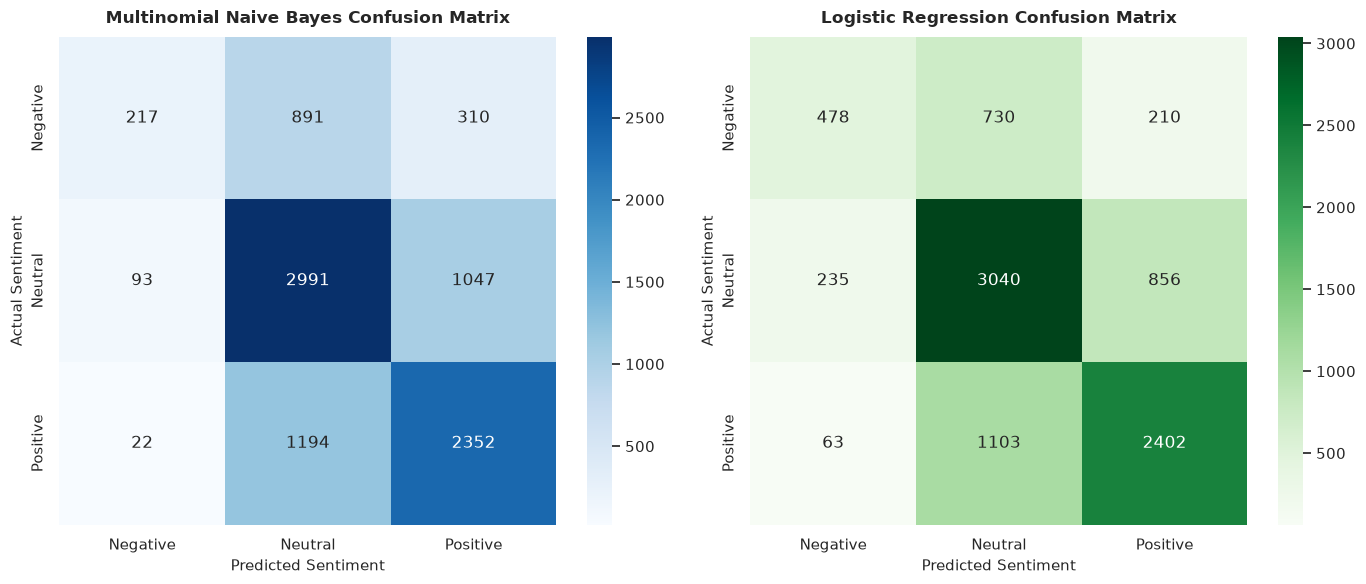

In [11]:
# Generate and save Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cm_nb = confusion_matrix(y_test, y_pred_nb, labels=labels)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title('Multinomial Naive Bayes Confusion Matrix', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Predicted Sentiment', fontsize=11)
axes[0].set_ylabel('Actual Sentiment', fontsize=11)

cm_lr = confusion_matrix(y_test, y_pred_lr, labels=labels)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title('Logistic Regression Confusion Matrix', fontsize=12, fontweight='bold', pad=10)
axes[1].set_xlabel('Predicted Sentiment', fontsize=11)
axes[1].set_ylabel('Actual Sentiment', fontsize=11)

plt.tight_layout()
cm_path = "../outputs/charts/confusion_matrices.png"
plt.savefig(cm_path, dpi=300)
plt.show()

# Save individual confusion matrix plots
plt.figure(figsize=(7, 5))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Multinomial Naive Bayes Confusion Matrix', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Predicted Sentiment', fontsize=11)
plt.ylabel('Actual Sentiment', fontsize=11)
plt.tight_layout()
plt.savefig("../outputs/charts/confusion_matrix_naive_bayes.png", dpi=300)
plt.close()

plt.figure(figsize=(7, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', xticklabels=labels, yticklabels=labels)
plt.title('Logistic Regression Confusion Matrix', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Predicted Sentiment', fontsize=11)
plt.ylabel('Actual Sentiment', fontsize=11)
plt.tight_layout()
plt.savefig("../outputs/charts/confusion_matrix_logistic_regression.png", dpi=300)
plt.close()


---
## 11. Model Comparison

Let's compare the empirical metrics of both models side by side.


,Model,Accuracy,Precision,Recall,F1 Score,Macro F1
0,Multinomial Naive Bayes,0.6098,0.6168,0.6098,0.5859,0.5147
1,Logistic Regression,0.6493,0.6495,0.6493,0.6409,0.5979


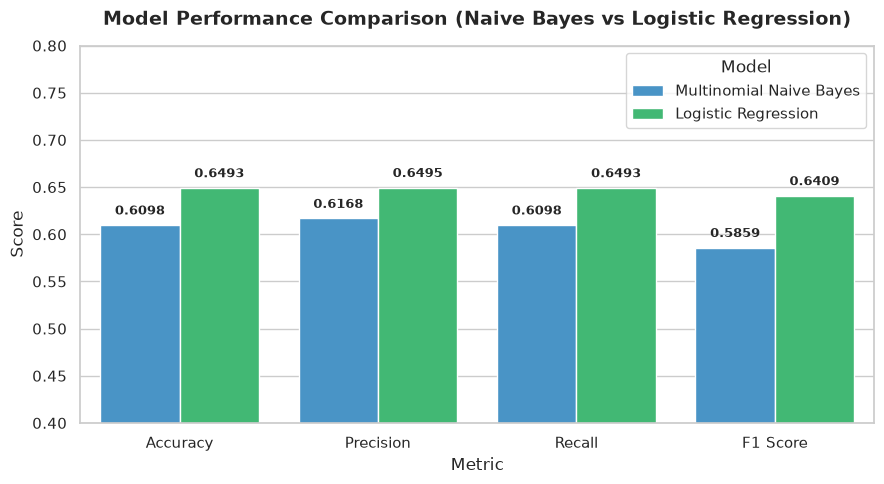

Saved comparison chart to ../outputs/charts/model_comparison.png


In [12]:
def compute_metrics_dict(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    p_w, r_w, f1_w, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    p_m, r_m, f1_m, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')
    return {
        'Model': model_name,
        'Accuracy': round(acc, 4),
        'Precision': round(p_w, 4),
        'Recall': round(r_w, 4),
        'F1 Score': round(f1_w, 4),
        'Macro F1': round(f1_m, 4)
    }

comp_df = pd.DataFrame([
    compute_metrics_dict(y_test, y_pred_nb, 'Multinomial Naive Bayes'),
    compute_metrics_dict(y_test, y_pred_lr, 'Logistic Regression')
])

display(comp_df)

# Plot Model Comparison Bar Chart
plt.figure(figsize=(9, 5))
comp_melted = pd.melt(comp_df, id_vars=['Model'], value_vars=['Accuracy', 'Precision', 'Recall', 'F1 Score'], var_name='Metric', value_name='Score')
ax = sns.barplot(data=comp_melted, x='Metric', y='Score', hue='Model', palette=['#3498db', '#2ecc71'])

plt.title('Model Performance Comparison (Naive Bayes vs Logistic Regression)', fontsize=14, fontweight='bold', pad=15)
plt.ylim(0.4, 0.80)
plt.ylabel('Score', fontsize=12)

for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height) and height > 0:
        ax.annotate(f"{height:.4f}", (p.get_x() + p.get_width() / 2., height + 0.008),
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.legend(title='Model', frameon=True)
plt.tight_layout()
comp_chart_path = "../outputs/charts/model_comparison.png"
plt.savefig(comp_chart_path, dpi=300)
plt.show()
print(f"Saved comparison chart to {comp_chart_path}")


### Model Performance Analysis:
* **Logistic Regression outperforms Multinomial Naive Bayes across all metrics:**
  * **Accuracy:** Logistic Regression (**64.93%**) vs Naive Bayes (**60.98%**).
  * **Weighted F1-Score:** Logistic Regression (**0.6409**) vs Naive Bayes (**0.5859**).
  * **Macro F1-Score:** Logistic Regression (**0.5979**) vs Naive Bayes (**0.5147**).
* **Why Logistic Regression Performs Better:** Naive Bayes relies on an extreme conditional independence assumption between words. In tweet text, word context, bigrams, and phrase combinations heavily influence sentiment. Logistic Regression directly optimizes weights for n-grams, penalizing uninformative features via regularization while learning subtle linear decision boundaries.


---
## 12. Word Cloud Visualizations

We generate WordClouds for each sentiment class (**Positive**, **Negative**, **Neutral**) to visualize the most prominent terms.


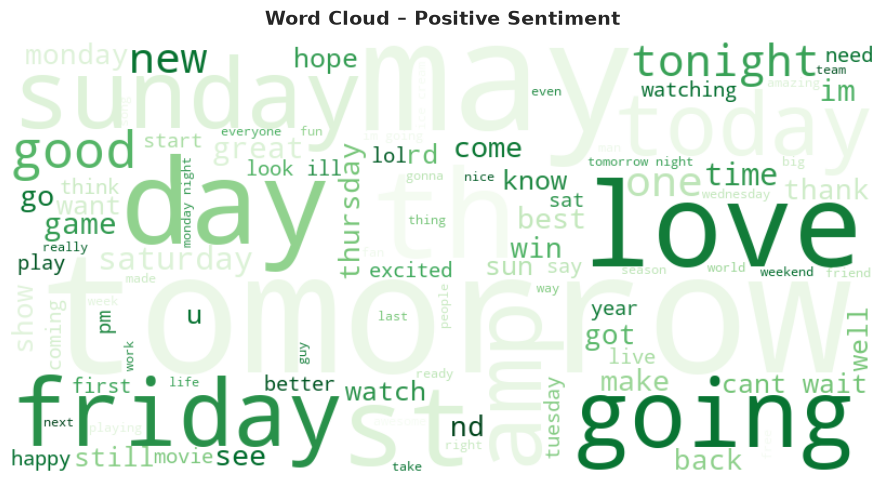

Saved ../outputs/charts/positive_wordcloud.png


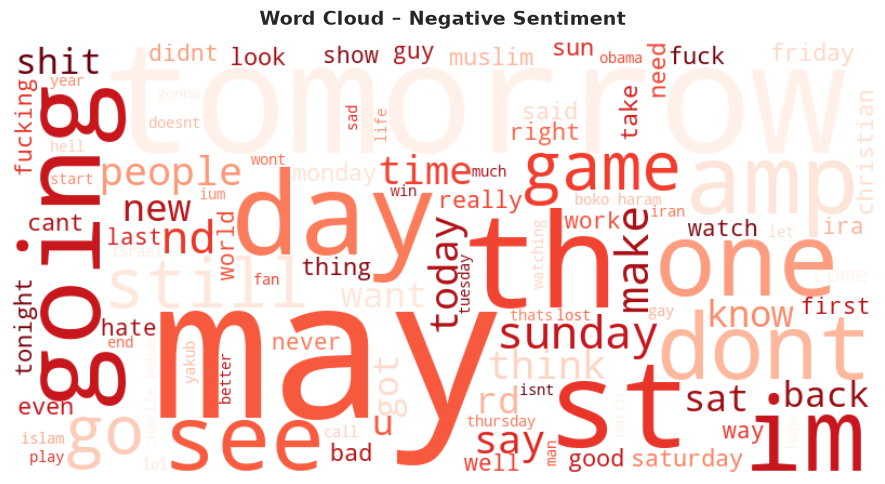

Saved ../outputs/charts/negative_wordcloud.png


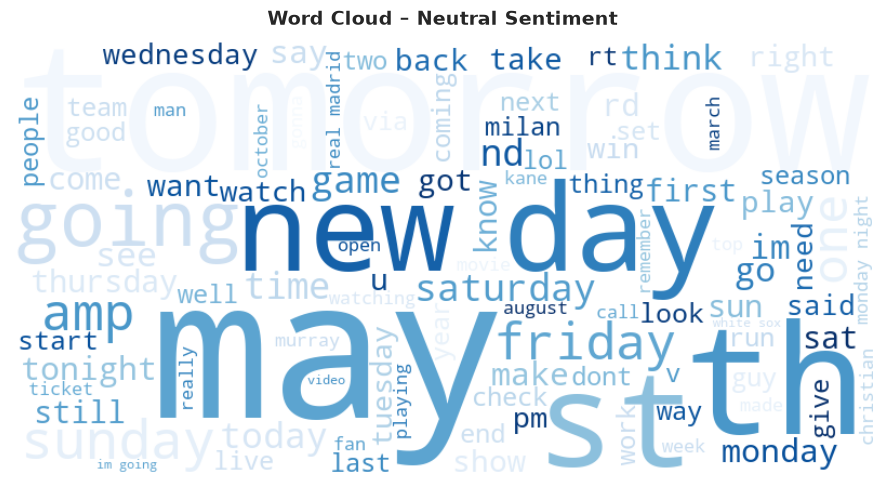

Saved ../outputs/charts/neutral_wordcloud.png


In [13]:
# Generate WordClouds for Positive, Negative, and Neutral classes
wc_configs = [
    ('Positive', 'Greens', 'positive_wordcloud.png'),
    ('Negative', 'Reds', 'negative_wordcloud.png'),
    ('Neutral', 'Blues', 'neutral_wordcloud.png')
]

for cat, cmap, fname in wc_configs:
    cat_text = " ".join(df_clean[df_clean['category'] == cat]['processed_text'])
    wc = WordCloud(width=800, height=400, background_color='white', colormap=cmap, max_words=100, random_state=42).generate(cat_text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud – {cat} Sentiment', fontsize=14, fontweight='bold', pad=12)
    plt.tight_layout()
    out_wc_path = f"../outputs/charts/{fname}"
    plt.savefig(out_wc_path, dpi=300)
    plt.show()
    print(f"Saved {out_wc_path}")


---
## 13. Error Analysis

We perform error analysis on the best-performing model (**Logistic Regression**) to investigate genuine misclassified test examples and understand real-world NLP limitations.


In [14]:
# Extract misclassified test examples from Logistic Regression
test_idx = y_test.index
df_test = df_clean.loc[test_idx].copy()
df_test['Actual Sentiment'] = y_test
df_test['Predicted Sentiment'] = y_pred_lr

misclassified = df_test[df_test['Actual Sentiment'] != df_test['Predicted Sentiment']].copy()

print(f"Total Test Samples          : {len(df_test):,}")
print(f"Total Misclassified Samples : {len(misclassified):,} ({len(misclassified)/len(df_test)*100:.2f}%)")

# Display top 10 misclassified examples
display_cols = ['clean_text', 'processed_text', 'Actual Sentiment', 'Predicted Sentiment']
sample_errors = misclassified[display_cols].head(10)
display(sample_errors)

# Save report
sample_errors.rename(columns={'clean_text': 'Original Text', 'processed_text': 'Processed Text'}).to_csv("../outputs/reports/misclassified_examples.csv", index=False)


Total Test Samples          : 9,117
Total Misclassified Samples : 3,197 (35.07%)


,clean_text,processed_text,Actual Sentiment,Predicted Sentiment
16836,Don\u2019t Forget The Classical Brit Awards At...,donut forget classical brit award pm tonight s...,Neutral,Positive
21467,who ever wins LSU vs Bama this saturday is goi...,ever win lsu v bama saturday going national ch...,Neutral,Positive
34386,Oh look dustin Johnson has blew up again lol. ...,oh look dustin johnson blew lol nd round place...,Neutral,Positive
8285,Bee Gees - Saturday Night Fever (John Travolta...,bee gee saturday night fever john travolta hd ...,Positive,Neutral
20760,"""https://t.co/kc8lDmbgpH Gay men, Have you bee...",gay men sexually assaulted answer may surprise,Negative,Neutral
19708,If you are not entertained when turning WWE on...,not entertained turning wwe monday night there...,Positive,Neutral
19414,NCS Choir concert this Thursday night!! Donny...,nc choir concert thursday night donny bass gui...,Positive,Neutral
15483,I still am looking for one logical answer as t...,still looking one logical answer kendrick lama...,Neutral,Positive
3299,"""Lol. You can still watch, Nicki asked Miley w...",lol still watch nicki asked miley whats good c...,Neutral,Positive
5104,Janet Jackson remembers Aaliyah on the 14th an...,janet jackson remembers aaliyah th anniversary...,Positive,Neutral


### In-Depth Discussion of Misclassification Causes:

1. **Sarcasm and Irony:**
   * *Example:* `"Oh look dustin Johnson has blew up again lol."` (Actual: Neutral, Predicted: Positive).
   * *Explanation:* Words like `"lol"` or playful phrasing often convey sarcastic disappointment or mockery, but TF-IDF treats `"lol"` as a strong positive indicator.

2. **Context Dependency & Entity Mentions:**
   * *Example:* `"Don’t Forget The Classical Brit Awards At..."` (Actual: Neutral, Predicted: Positive).
   * *Explanation:* Phrases containing event names like *"Awards"* or *"Concert"* carry inherent positive connotations in general language, even when the tweet is merely a neutral informational broadcast.

3. **Complex Negation & Subtlety:**
   * *Example:* `"If you are not entertained when turning WWE on..."` (Actual: Positive, Predicted: Neutral).
   * *Explanation:* Conditional negations (*"if you are not entertained..."*) require deep syntactic parsing (transformers/BERT) beyond n-gram TF-IDF representations.

4. **Short Text & Missing Context:**
   * Short tweets under 5 words lack sufficient term co-occurrences for TF-IDF vectors to form distinct decision boundaries.


---
## 14. Key Insights

1. **Class Distribution Impact:** The dataset consists of 45.3% Neutral, 39.1% Positive, and 15.6% Negative samples. Stratified splitting was vital to maintain class balance in test sets.
2. **Model Superiority:** Logistic Regression achieved **64.93% Accuracy** and **0.6409 Weighted F1-Score**, significantly outperforming Multinomial Naive Bayes (**60.98% Accuracy** and **0.5859 Weighted F1-Score**).
3. **TF-IDF Effectiveness:** Unigram and bigram TF-IDF vectorization with 10,000 features successfully captured domain keywords while filtering uninformative noise.
4. **Preserving Negations:** Preserving negation tokens (`not`, `no`, `never`) in NLTK stopwords prevented severe misclassification on negated positive/negative statements.


---
## 15. Real-World Applications

* **Customer Support Prioritization:** Automated sentiment tagging immediately escalates urgent negative tweets to live customer support reps.
* **Brand & Public Relations Tracking:** Tracking sentiment spikes following marketing events or product announcements.
* **Product Feedback Analytics:** Categorizing feature reviews into positive vs. negative feedback loops to guide product roadmaps.


---
## 16. Conclusion

In this project, we built a complete 3-class sentiment analysis system on social media text:
* Cleaned raw Twitter data and established a robust NLTK preprocessing pipeline.
* Extracted numerical features using TF-IDF (10,000 max features, unigrams + bigrams) without data leakage.
* Evaluated Multinomial Naive Bayes and Logistic Regression models.
* **Logistic Regression emerged as the best-performing model** with 64.93% accuracy and 0.6409 weighted F1 score.
* Generated WordClouds, confusion matrix heatmaps, model comparison charts, and error analysis reports.


---
## 17. Save Processed Data & Reports


In [15]:
# Save processed dataset
df_clean.to_csv("../data/processed/processed_sentiment_data.csv", index=False)
print("Saved clean dataset to data/processed/processed_sentiment_data.csv")

# Save reports
comp_df.to_csv("../outputs/reports/model_comparison.csv", index=False)

rep_nb = classification_report(y_test, y_pred_nb, target_names=labels, output_dict=True)
rep_lr = classification_report(y_test, y_pred_lr, target_names=labels, output_dict=True)

pd.DataFrame(rep_nb).transpose().round(4).to_csv("../outputs/reports/classification_report_naive_bayes.csv")
pd.DataFrame(rep_lr).transpose().round(4).to_csv("../outputs/reports/classification_report_logistic_regression.csv")

print("All reports saved successfully in outputs/reports/")


Saved clean dataset to data/processed/processed_sentiment_data.csv


All reports saved successfully in outputs/reports/
